
<table width="100%" style="padding:0; margin-left:-6px;">
    <tr style="padding=0;" width="100%">
        <td width="auto">
           <hr style="border:2px solid darkblue">
            <h1> nb2. Query a catalogue</h1>
           <hr style="border:2px solid darkblue">
        </td>
        <td width="60px">
           <img src="ALMAsmall.png" align="right"/> 
        </td>
    </tr>
</table>    
        
In this notebook three functions are presented which query a (moderately long) list of sources from a catalogue: 

* By coordinate
* By resolved name using Sesame
* By ALMA source name

For lists with a very large number of sources, run one query per block of 100 sources. See Example 2b and Example 2d.

-------------

The relevant columns in the ALMA Archive datasets are 
* *s_ra*, *s_dec* (RA and Dec in degress)
* *s_region* (STC-S footprint of the observation) 
* *target_name* (source name)
 
--------- ----- -----





In [1]:
import astropy
import astropy.coordinates
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import pyvo
import matplotlib.pyplot as plt

service = pyvo.dal.TAPService("https://almascience.eso.org/tap")      # for the EU ALMA TAP service

# service = pyvo.dal.TAPService("https://almascience.nao.ac.jp/tap")  # for the EA ALMA TAP service
# service = pyvo.dal.TAPService("https://almascience.nrao.edu/tap")   # for the NA ALMA TAP service

<hr style="border:2px solid darkblue"> </hr>

## Query list of coordinates

<hr style="border:2px solid darkblue"> </hr>


In [2]:
def query_coordinate_list(service, ra_list, dec_list, radius):
    """Runs a single query for an entire list of coordinates. Query only 100 or less coordinates in one go.
    
       service        pyvo TAPService instance           
       ra_list        List of Right Ascension values in decimal degrees
       dec            List of Declination values in decimal degrees
       radius         Search radius in decimal degrees
           
       returns        pandas table
    """
    
    conditionlist = [f"INTERSECTS(CIRCLE('ICRS',{c[0]},{c[1]},{radius}),s_region)=1" for c in zip(ra_list, dec_list)]
    
    query = f"""
            SELECT *
            FROM ivoa.obscore
            WHERE {" OR ".join(conditionlist)}"""
    
    return service.search(query).to_table().to_pandas()

<hr style="border:2px solid darkblue"> </hr>

## Query list of resolved names

<hr style="border:2px solid darkblue"> </hr>

In [3]:
def query_resolved_source_name_list(service, source_name_list, radius):
    """Resolves the list of source names with Sesame and runs a coordinate search on them
    
       service           pyvo TAPService instance           
       source_name_list  list with source names
           
       returns           pandas table
    """
    
    coordinates = []
    for source in source_name_list:
        try:
            coordinates.append(astropy.coordinates.SkyCoord.from_name(source))
        except astropy.coordinates.name_resolve.NameResolveError:
            print(f"Warning: source '{source}' could not be resolved by Sesame.")
            
    return query_coordinate_list(service, [c.ra.degree for c in coordinates], [c.dec.degree for c in coordinates], radius)
    

<hr style="border:2px solid darkblue"> </hr>


## Query list of ALMA source names
<hr style="border:2px solid darkblue"> </hr>



In [4]:
def query_alma_source_name_list(service, source_name_list):
    """queries for list of source names as given by the PI in the ALMA proposals
    
       service            pyvo TAPService instance           
       source_name_lis    complete source name 
           
       returns            pandas table
    """
    
    query = f"""  
            SELECT *  
            FROM ivoa.obscore  
            WHERE target_name in ('{"','".join(source_name_list)}') """
    
    return service.search(query).to_table().to_pandas()

-----------------

## Example 2a: Query a catalogue of high-z quasars

First we import a catalogue of high redshift quasars from [VizieR](https://vizier.u-strasbg.fr/viz-bin/VizieR), using astroquery:

In [5]:
from astroquery.vizier import Vizier
catalog_list = Vizier.get_catalogs('J/ApJS/227/11')
highzqso_catalog = catalog_list['J/ApJS/227/11/highzqso']
print(f"Number of (limited) rows in the catalog: {len(highzqso_catalog)}")

Number of (limited) rows in the catalog: 50


Note: VizieR limits the number of catalogue entries to 50 per default. We will now use the RA and Dec coordinates in the catalogue to do the search in the ALMA archive. 

In [6]:
ra_list = highzqso_catalog['RAJ2000']
dec_list = highzqso_catalog['DEJ2000']

We now query the ALMA archive:


In [7]:
results = query_coordinate_list(service, ra_list, dec_list, 0.01)
results.head(5) ### show only 5, for visualization purposes

,access_url,access_format,proposal_id,data_rights,gal_longitude,gal_latitude,obs_publisher_did,obs_collection,facility_name,instrument_name,obs_id,dataproduct_type,calib_level,target_name,s_ra,s_dec,s_fov,s_region,s_resolution,t_min,t_max,t_exptime,t_resolution,em_min,em_max,em_res_power,pol_states,o_ucd,band_list,em_resolution,authors,pub_abstract,publication_year,proposal_abstract,schedblock_name,proposal_authors,sensitivity_10kms,cont_sensitivity_bandwidth,pwv,group_ous_uid,member_ous_uid,asdm_uid,obs_title,type,scan_intent,science_observation,spatial_scale_max,bandwidth,antenna_arrays,is_mosaic,obs_release_date,spatial_resolution,frequency_support,frequency,velocity_resolution,obs_creator_name,pub_title,first_author,qa2_passed,bib_reference,science_keyword,scientific_category,lastModified
0,http://almascience.org/aq?member_ous_id=uid://...,text/html,2011.0.00206.S,Public,143.742975,-61.898944,ADS/JAO.ALMA#2011.0.00206.S,ALMA,JAO,ALMA,uid://A002/X391d0b/X22,image,2,J0129-0035,22.493792,-0.594361,0.005630,Circle ICRS 22.493792 -0.594361 0.002815,0.473461,56069.496754,56069.574857,2661.12,2661.12,0.001066,0.001073,9002.45608,/XX/YY/,phot.flux.density;phys.polarization,7,9.593760,"Champagne, Jaclyn B.; Decarli, Roberto; Casey,...",Bright high-redshift quasars (z &gt; 6) hostin...,2013,Huge amounts of far-infrared (FIR)-emitting wa...,J0129-0035,"Narayanan, Desika; Riechers, Dominik; Fan, Xia...",1.040025,0.037899,0.90717,,uid://A002/X391d0b/X22,uid://A002/X411025/X6d7,Dust continum and [C II] line emission from qu...,S,TARGET,T,4.264570,2.000000e+09,A003:DA41 A004:DV04 A011:DV12 A021:DV08 A025:D...,F,2013-06-25T16:06:00.000,0.473461,"[279.33..281.31GHz,31250.00kHz,1mJy/beam@10km/...",287.322530,31722.538623,"Wang, Ran",Dynamical Characterization of Galaxies at z ∼ ...,"Champagne, Jaclyn B. Jones, G. C. Miller, Tim ...",T,2013ApJ...773...44W 2014ApJ...795....5O 2017Ap...,"High-z Active Galactic Nuclei (AGN), Active Ga...",Active galaxies,2021-09-30T16:34:41.133
1,http://almascience.org/aq?member_ous_id=uid://...,text/html,2011.0.00206.S,Public,143.742975,-61.898944,ADS/JAO.ALMA#2011.0.00206.S,ALMA,JAO,ALMA,uid://A002/X391d0b/X22,image,2,J0129-0035,22.493792,-0.594361,0.005630,Circle ICRS 22.493792 -0.594361 0.002815,0.473461,56069.496754,56069.574857,2661.12,2661.12,0.001022,0.001029,9386.45608,/XX/YY/,phot.flux.density;phys.polarization,7,9.593760,"Champagne, Jaclyn B.; Decarli, Roberto; Casey,...",Bright high-redshift quasars (z &gt; 6) hostin...,2013,Huge amounts of far-infrared (FIR)-emitting wa...,J0129-0035,"Narayanan, Desika; Riechers, Dominik; Fan, Xia...",1.152586,0.037899,0.90717,,uid://A002/X391d0b/X22,uid://A002/X411025/X6d7,Dust continum and [C II] line emission from qu...,S,TARGET,T,4.264570,2.000000e+09,A003:DA41 A004:DV04 A011:DV12 A021:DV08 A025:D...,F,2013-06-25T16:06:00.000,0.473461,"[279.33..281.31GHz,31250.00kHz,1mJy/beam@10km/...",287.322530,31722.538623,"Wang, Ran",Dynamical Characterization of Galaxies at z ∼ ...,"Champagne, Jaclyn B. Jones, G. C. Miller, Tim ...",T,2013ApJ...773...44W 2014ApJ...795....5O 2017Ap...,"High-z Active Galactic Nuclei (AGN), Active Ga...",Active galaxies,2021-09-30T16:34:41.133
2,http://almascience.org/aq?member_ous_id=uid://...,text/html,2011.0.00206.S,Public,143.742975,-61.898944,ADS/JAO.ALMA#2011.0.00206.S,ALMA,JAO,ALMA,uid://A002/X391d0b/X22,image,2,J0129-0035,22.493792,-0.594361,0.005630,Circle ICRS 22.493792 -0.594361 0.002815,0.473461,56069.496754,56069.574857,2661.12,2661.12,0.001058,0.001066,9064.45608,/XX/YY/,phot.flux.density;phys.polarization,7,9.593760,"Champagne, Jaclyn B.; Decarli, Roberto; Casey,...",Bright high-redshift quasars (z &gt; 6) hostin...,2013,Huge amounts of far-infrared (FIR)-emitting wa...,J0129-0035,"Narayanan, Desika; Riechers, Dominik; Fan, Xia...",1.049808,0.037899,0.90717,,uid://A002/X391d0b/X22,uid://A002/X411025/X6d7,Dust continum and [C II] line emission from qu...,S,TARGET,T,4.264570,2.000000e+09,A003:DA41 A004:DV04 A011:DV12 A021:DV08 A0

We can now plot the distribution of ALMA observed quasars from the chosen catalogue.

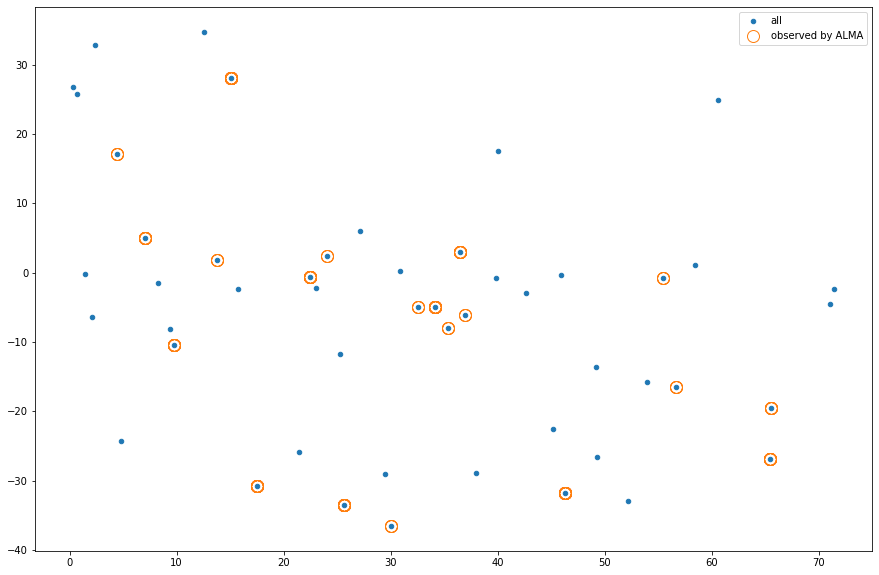

In [8]:
plt.rcParams["figure.figsize"] = (15,10)

plt.plot(ra_list, dec_list, ls='', marker='.', ms=9, label='all')
plt.plot(results['s_ra'],results['s_dec'], ls='', marker='o', ms=12, fillstyle='none', label='observed by ALMA')
plt.legend()

Please run several queries in case the number of sources in your list is very large.

-----------------

## Example 2b: Query a large catalogue with many sources



Not more than 100 sources should be submitted in a single query. For large catalogues, several queries should be submitted consecutively. Explicitly telling VizieR that no limit shall be placed on the results to return, we obtain:

In [9]:
Vizier.ROW_LIMIT=999999999

catalog_list = Vizier.get_catalogs('J/ApJS/227/11')
highzqso_catalog = catalog_list['J/ApJS/227/11/highzqso']
print(f"Number of (unlimited) rows in the catalog: {len(highzqso_catalog)}")
ra_list = highzqso_catalog['RAJ2000']
dec_list = highzqso_catalog['DEJ2000']

Number of (unlimited) rows in the catalog: 173


We will now use the RA and Dec coordinates in the catalogue to do the search in the ALMA archive in chunks of 100 results. These results are then combined back into a single pandas table.

In [10]:
result = pd.concat([query_coordinate_list(service, ra_list[i:i+100], dec_list[i:i+100], 0.01) for i in range(0, len(ra_list), 100)])

In [11]:
print(f"Number of ALMA rows returned for the {len(highzqso_catalog)} catalog entries: {len(result)}")
results.head(5) ### show only 5, for visualization purposes

Number of ALMA rows returned for the 173 catalog entries: 704


,access_url,access_format,proposal_id,data_rights,gal_longitude,gal_latitude,obs_publisher_did,obs_collection,facility_name,instrument_name,obs_id,dataproduct_type,calib_level,target_name,s_ra,s_dec,s_fov,s_region,s_resolution,t_min,t_max,t_exptime,t_resolution,em_min,em_max,em_res_power,pol_states,o_ucd,band_list,em_resolution,authors,pub_abstract,publication_year,proposal_abstract,schedblock_name,proposal_authors,sensitivity_10kms,cont_sensitivity_bandwidth,pwv,group_ous_uid,member_ous_uid,asdm_uid,obs_title,type,scan_intent,science_observation,spatial_scale_max,bandwidth,antenna_arrays,is_mosaic,obs_release_date,spatial_resolution,frequency_support,frequency,velocity_resolution,obs_creator_name,pub_title,first_author,qa2_passed,bib_reference,science_keyword,scientific_category,lastModified
0,http://almascience.org/aq?member_ous_id=uid://...,text/html,2011.0.00206.S,Public,143.742975,-61.898944,ADS/JAO.ALMA#2011.0.00206.S,ALMA,JAO,ALMA,uid://A002/X391d0b/X22,image,2,J0129-0035,22.493792,-0.594361,0.005630,Circle ICRS 22.493792 -0.594361 0.002815,0.473461,56069.496754,56069.574857,2661.12,2661.12,0.001066,0.001073,9002.45608,/XX/YY/,phot.flux.density;phys.polarization,7,9.593760,"Champagne, Jaclyn B.; Decarli, Roberto; Casey,...",Bright high-redshift quasars (z &gt; 6) hostin...,2013,Huge amounts of far-infrared (FIR)-emitting wa...,J0129-0035,"Narayanan, Desika; Riechers, Dominik; Fan, Xia...",1.040025,0.037899,0.90717,,uid://A002/X391d0b/X22,uid://A002/X411025/X6d7,Dust continum and [C II] line emission from qu...,S,TARGET,T,4.264570,2.000000e+09,A003:DA41 A004:DV04 A011:DV12 A021:DV08 A025:D...,F,2013-06-25T16:06:00.000,0.473461,"[279.33..281.31GHz,31250.00kHz,1mJy/beam@10km/...",287.322530,31722.538623,"Wang, Ran",Dynamical Characterization of Galaxies at z ∼ ...,"Champagne, Jaclyn B. Jones, G. C. Miller, Tim ...",T,2013ApJ...773...44W 2014ApJ...795....5O 2017Ap...,"High-z Active Galactic Nuclei (AGN), Active Ga...",Active galaxies,2021-09-30T16:34:41.133
1,http://almascience.org/aq?member_ous_id=uid://...,text/html,2011.0.00206.S,Public,143.742975,-61.898944,ADS/JAO.ALMA#2011.0.00206.S,ALMA,JAO,ALMA,uid://A002/X391d0b/X22,image,2,J0129-0035,22.493792,-0.594361,0.005630,Circle ICRS 22.493792 -0.594361 0.002815,0.473461,56069.496754,56069.574857,2661.12,2661.12,0.001022,0.001029,9386.45608,/XX/YY/,phot.flux.density;phys.polarization,7,9.593760,"Champagne, Jaclyn B.; Decarli, Roberto; Casey,...",Bright high-redshift quasars (z &gt; 6) hostin...,2013,Huge amounts of far-infrared (FIR)-emitting wa...,J0129-0035,"Narayanan, Desika; Riechers, Dominik; Fan, Xia...",1.152586,0.037899,0.90717,,uid://A002/X391d0b/X22,uid://A002/X411025/X6d7,Dust continum and [C II] line emission from qu...,S,TARGET,T,4.264570,2.000000e+09,A003:DA41 A004:DV04 A011:DV12 A021:DV08 A025:D...,F,2013-06-25T16:06:00.000,0.473461,"[279.33..281.31GHz,31250.00kHz,1mJy/beam@10km/...",287.322530,31722.538623,"Wang, Ran",Dynamical Characterization of Galaxies at z ∼ ...,"Champagne, Jaclyn B. Jones, G. C. Miller, Tim ...",T,2013ApJ...773...44W 2014ApJ...795....5O 2017Ap...,"High-z Active Galactic Nuclei (AGN), Active Ga...",Active galaxies,2021-09-30T16:34:41.133
2,http://almascience.org/aq?member_ous_id=uid://...,text/html,2011.0.00206.S,Public,143.742975,-61.898944,ADS/JAO.ALMA#2011.0.00206.S,ALMA,JAO,ALMA,uid://A002/X391d0b/X22,image,2,J0129-0035,22.493792,-0.594361,0.005630,Circle ICRS 22.493792 -0.594361 0.002815,0.473461,56069.496754,56069.574857,2661.12,2661.12,0.001058,0.001066,9064.45608,/XX/YY/,phot.flux.density;phys.polarization,7,9.593760,"Champagne, Jaclyn B.; Decarli, Roberto; Casey,...",Bright high-redshift quasars (z &gt; 6) hostin...,2013,Huge amounts of far-infrared (FIR)-emitting wa...,J0129-0035,"Narayanan, Desika; Riechers, Dominik; Fan, Xia...",1.049808,0.037899,0.90717,,uid://A002/X391d0b/X22,uid://A002/X411025/X6d7,Dust continum and [C II] line emission from qu...,S,TARGET,T,4.264570,2.000000e+09,A003:DA41 A004:DV04 A011:DV12 A021:DV08 A0

We can now plot the distribution of ALMA observed quasars from the chosen catalogue.

-----------------

## Example 2c: Query a list of sources using a name resolver

The function query_resolved_source_name_list will query Sesame for each source name and then query the ALMA TAP service with the returned coordinates. If a source is not known by Sesame (like the 'unknownsourcename' we have put in explicitly), then the function writes out a warning.

In [12]:
source_name_list = ['CenA', 'M83', 'ALESS73.1', 'unknownsourcename'] 
query_resolved_source_name_list(service, source_name_list, 0.01).head(5)

,access_url,access_format,proposal_id,data_rights,gal_longitude,gal_latitude,obs_publisher_did,obs_collection,facility_name,instrument_name,obs_id,dataproduct_type,calib_level,target_name,s_ra,s_dec,s_fov,s_region,s_resolution,t_min,t_max,t_exptime,t_resolution,em_min,em_max,em_res_power,pol_states,o_ucd,band_list,em_resolution,authors,pub_abstract,publication_year,proposal_abstract,schedblock_name,proposal_authors,sensitivity_10kms,cont_sensitivity_bandwidth,pwv,group_ous_uid,member_ous_uid,asdm_uid,obs_title,type,scan_intent,science_observation,spatial_scale_max,bandwidth,antenna_arrays,is_mosaic,obs_release_date,spatial_resolution,frequency_support,frequency,velocity_resolution,obs_creator_name,pub_title,first_author,qa2_passed,bib_reference,science_keyword,scientific_category,lastModified
0,http://almascience.org/aq?member_ous_id=uid://...,text/html,2011.0.00008.SV,Public,309.512363,19.416239,ADS/JAO.ALMA#2011.0.00008.SV,ALMA,JAO,ALMA,uid://A002/X259150/X157,cube,2,Centaurus A,201.360719,-43.020553,0.058089,Polygon ICRS 201.401254 -43.032096 201.401354 ...,1.023315,55784.795689,55785.043473,344.261,344.261,0.001221,0.001231,251315.70776,/XX/YY/,phot.flux.density;phys.polarization,6,306.959997,"Azeez, Jazeel H.; Abidin, Zamri Z.; Hwang, C. ...","Centaurus A, with its gas-rich elliptical host...",2014,Science Verification (SV) is the process by wh...,CenA mosaic,,13.319542,0.432702,1.663192,,uid://A002/X259150/X157,uid://A002/X2762c7/X132,Science verification observation of Centaurus A,SV,TARGET WVR,T,9.714115,1.875000e+09,A004:DV07 A008:DV09 A009:DA41 A011:DV12 A015:D...,T,2016-06-24T14:02:07.000,1.023315,"[229.20..231.08GHz,976.56kHz,13.2mJy/beam@10km...",238.261613,1183.847494,"observatory, ALMA",ALMA Observations of the Physical and Chemical...,"Azeez, Jazeel H. Israel, F. P. McCoy, Mark",T,2014A&A...562A..96I 2017AdAst2017E...6A 2017Ap...,"Galactic centres/nuclei, Active Galactic Nucle...",Active galaxies,2021-09-30T16:34:41.133
1,http://almascience.org/aq?member_ous_id=uid://...,text/html,2011.0.00008.SV,Public,309.512363,19.416239,ADS/JAO.ALMA#2011.0.00008.SV,ALMA,JAO,ALMA,uid://A002/X259150/X157,cube,2,Centaurus A,201.360719,-43.020553,0.058089,Polygon ICRS 201.401254 -43.032096 201.401354 ...,1.023315,55784.795689,55785.043473,344.261,344.261,0.001212,0.001221,253235.70776,/XX/YY/,phot.flux.density;phys.polarization,6,306.959997,"Azeez, Jazeel H.; Abidin, Zamri Z.; Hwang, C. ...","Centaurus A, with its gas-rich elliptical host...",2014,Science Verification (SV) is the process by wh...,CenA mosaic,,13.283133,0.432702,1.663192,,uid://A002/X259150/X157,uid://A002/X2762c7/X132,Science verification observation of Centaurus A,SV,TARGET WVR,T,9.714115,1.875000e+09,A004:DV07 A008:DV09 A009:DA41 A011:DV12 A015:D...,T,2016-06-24T14:02:07.000,1.023315,"[229.20..231.08GHz,976.56kHz,13.2mJy/beam@10km...",238.261613,1183.847494,"observatory, ALMA",ALMA Observations of the Physical and Chemical...,"Azeez, Jazeel H. Israel, F. P. McCoy, Mark",T,2014A&A...562A..96I 2017AdAst2017E...6A 2017Ap...,"Galactic centres/nuclei, Active Galactic Nucle...",Active galaxies,2021-09-30T16:34:41.133
2,http://almascience.org/aq?member_ous_id=uid://...,text/html,2011.0.00008.SV,Public,309.512363,19.416239,ADS/JAO.ALMA#2011.0.00008.SV,ALMA,JAO,ALMA,uid://A002/X259150/X157,cube,2,Centaurus A,201.360719,-43.020553,0.058089,Polygon ICRS 201.401254 -43.032096 201.401354 ...,1.023315,55784.795689,55785.043473,344.261,344.261,0.001297,0.001308,236599.53752,/XX/YY/,phot.flux.density;phys.polarization,6,306.959997,"Azeez, Jazeel H.; Abidin, Zamri Z.; Hwang, C. ...","Centaurus A, with its gas-rich elliptical host...",2014,Science Verification (SV) is the process by wh...,CenA mosaic,,13.238502,0.432702,1.663192,,uid://A002/X259150/X157,uid://A002/X2762c7/X132,Science verification observation of Centaurus A,SV,TARGET WVR,T,9.714115,1.875000e+09,A004:DV07 A008:DV09 A009:DA41 A011:DV12 A015:D...,T,2016-06-24T14:02:07.000,1.023315,"[229.20..231.08GHz,976.56kHz,13

-----------------

## Example 2d: Query a long list of sources using a name resolver

We query a lisf of many sources in groups of 100 sources at a time and combine the result into a single pandas dataframe.

In [13]:
query = """SELECT DISTINCT(target_name) from ivoa.obscore where target_name like 'NGC____'"""
source_name_list = list(service.search(query).to_table().to_pandas()['(target_name)'].values)

In [14]:
result = pd.concat([query_resolved_source_name_list(service, source_name_list[i:i+100], 0.006) for i in range(0, len(source_name_list), 100)])
print(f"Number of ALMA rows returned for the {len(source_name_list)} sources in the list: {len(result)}")
results.head(5)

Number of ALMA rows returned for the 320 sources in the list: 6252


,access_url,access_format,proposal_id,data_rights,gal_longitude,gal_latitude,obs_publisher_did,obs_collection,facility_name,instrument_name,obs_id,dataproduct_type,calib_level,target_name,s_ra,s_dec,s_fov,s_region,s_resolution,t_min,t_max,t_exptime,t_resolution,em_min,em_max,em_res_power,pol_states,o_ucd,band_list,em_resolution,authors,pub_abstract,publication_year,proposal_abstract,schedblock_name,proposal_authors,sensitivity_10kms,cont_sensitivity_bandwidth,pwv,group_ous_uid,member_ous_uid,asdm_uid,obs_title,type,scan_intent,science_observation,spatial_scale_max,bandwidth,antenna_arrays,is_mosaic,obs_release_date,spatial_resolution,frequency_support,frequency,velocity_resolution,obs_creator_name,pub_title,first_author,qa2_passed,bib_reference,science_keyword,scientific_category,lastModified
0,http://almascience.org/aq?member_ous_id=uid://...,text/html,2011.0.00206.S,Public,143.742975,-61.898944,ADS/JAO.ALMA#2011.0.00206.S,ALMA,JAO,ALMA,uid://A002/X391d0b/X22,image,2,J0129-0035,22.493792,-0.594361,0.005630,Circle ICRS 22.493792 -0.594361 0.002815,0.473461,56069.496754,56069.574857,2661.12,2661.12,0.001066,0.001073,9002.45608,/XX/YY/,phot.flux.density;phys.polarization,7,9.593760,"Champagne, Jaclyn B.; Decarli, Roberto; Casey,...",Bright high-redshift quasars (z &gt; 6) hostin...,2013,Huge amounts of far-infrared (FIR)-emitting wa...,J0129-0035,"Narayanan, Desika; Riechers, Dominik; Fan, Xia...",1.040025,0.037899,0.90717,,uid://A002/X391d0b/X22,uid://A002/X411025/X6d7,Dust continum and [C II] line emission from qu...,S,TARGET,T,4.264570,2.000000e+09,A003:DA41 A004:DV04 A011:DV12 A021:DV08 A025:D...,F,2013-06-25T16:06:00.000,0.473461,"[279.33..281.31GHz,31250.00kHz,1mJy/beam@10km/...",287.322530,31722.538623,"Wang, Ran",Dynamical Characterization of Galaxies at z ∼ ...,"Champagne, Jaclyn B. Jones, G. C. Miller, Tim ...",T,2013ApJ...773...44W 2014ApJ...795....5O 2017Ap...,"High-z Active Galactic Nuclei (AGN), Active Ga...",Active galaxies,2021-09-30T16:34:41.133
1,http://almascience.org/aq?member_ous_id=uid://...,text/html,2011.0.00206.S,Public,143.742975,-61.898944,ADS/JAO.ALMA#2011.0.00206.S,ALMA,JAO,ALMA,uid://A002/X391d0b/X22,image,2,J0129-0035,22.493792,-0.594361,0.005630,Circle ICRS 22.493792 -0.594361 0.002815,0.473461,56069.496754,56069.574857,2661.12,2661.12,0.001022,0.001029,9386.45608,/XX/YY/,phot.flux.density;phys.polarization,7,9.593760,"Champagne, Jaclyn B.; Decarli, Roberto; Casey,...",Bright high-redshift quasars (z &gt; 6) hostin...,2013,Huge amounts of far-infrared (FIR)-emitting wa...,J0129-0035,"Narayanan, Desika; Riechers, Dominik; Fan, Xia...",1.152586,0.037899,0.90717,,uid://A002/X391d0b/X22,uid://A002/X411025/X6d7,Dust continum and [C II] line emission from qu...,S,TARGET,T,4.264570,2.000000e+09,A003:DA41 A004:DV04 A011:DV12 A021:DV08 A025:D...,F,2013-06-25T16:06:00.000,0.473461,"[279.33..281.31GHz,31250.00kHz,1mJy/beam@10km/...",287.322530,31722.538623,"Wang, Ran",Dynamical Characterization of Galaxies at z ∼ ...,"Champagne, Jaclyn B. Jones, G. C. Miller, Tim ...",T,2013ApJ...773...44W 2014ApJ...795....5O 2017Ap...,"High-z Active Galactic Nuclei (AGN), Active Ga...",Active galaxies,2021-09-30T16:34:41.133
2,http://almascience.org/aq?member_ous_id=uid://...,text/html,2011.0.00206.S,Public,143.742975,-61.898944,ADS/JAO.ALMA#2011.0.00206.S,ALMA,JAO,ALMA,uid://A002/X391d0b/X22,image,2,J0129-0035,22.493792,-0.594361,0.005630,Circle ICRS 22.493792 -0.594361 0.002815,0.473461,56069.496754,56069.574857,2661.12,2661.12,0.001058,0.001066,9064.45608,/XX/YY/,phot.flux.density;phys.polarization,7,9.593760,"Champagne, Jaclyn B.; Decarli, Roberto; Casey,...",Bright high-redshift quasars (z &gt; 6) hostin...,2013,Huge amounts of far-infrared (FIR)-emitting wa...,J0129-0035,"Narayanan, Desika; Riechers, Dominik; Fan, Xia...",1.049808,0.037899,0.90717,,uid://A002/X391d0b/X22,uid://A002/X411025/X6d7,Dust continum and [C II] line emission from qu...,S,TARGET,T,4.264570,2.000000e+09,A003:DA41 A004:DV04 A011:DV12 A021:DV08 A0

-----------------

## Example 2e: Query a list of sources using the ALMA source name

Although in most cases the coordinate query or the source name resolving queries should be preferred, there may be occasions where it is useful to query directly for the source name as given by the PI.

In [15]:
source_name_list = ['CenA', 'M83', 'ALESS73.1'] 
results = query_alma_source_name_list(service, source_name_list)

results.head(5)

,access_url,access_format,proposal_id,data_rights,gal_longitude,gal_latitude,obs_publisher_did,obs_collection,facility_name,instrument_name,obs_id,dataproduct_type,calib_level,target_name,s_ra,s_dec,s_fov,s_region,s_resolution,t_min,t_max,t_exptime,t_resolution,em_min,em_max,em_res_power,pol_states,o_ucd,band_list,em_resolution,authors,pub_abstract,publication_year,proposal_abstract,schedblock_name,proposal_authors,sensitivity_10kms,cont_sensitivity_bandwidth,pwv,group_ous_uid,member_ous_uid,asdm_uid,obs_title,type,scan_intent,science_observation,spatial_scale_max,bandwidth,antenna_arrays,is_mosaic,obs_release_date,spatial_resolution,frequency_support,frequency,velocity_resolution,obs_creator_name,pub_title,first_author,qa2_passed,bib_reference,science_keyword,scientific_category,lastModified
0,http://almascience.org/aq?member_ous_id=uid://...,text/html,2011.0.00010.S,Public,309.515914,19.417224,ADS/JAO.ALMA#2011.0.00010.S,ALMA,JAO,ALMA,uid://A002/X327408/X217,cube,2,CenA,201.365063,-43.019112,0.007385,Circle ICRS 201.365063 -43.019112 0.003692,1.330912,55950.253573,55950.305961,1512.000,1512.000,0.001360,0.001366,451534.98200,/XX/YY/,phot.flux.density;phys.polarization,6,614.023326,"McCoy, Mark; Ott, Jürgen; Meier, David S.; Mul...","Centaurus A, with its gas-rich elliptical host...",2017,Centaurus A with its host NGC5128 is the most ...,"CenA 13CO, C18O, HNCO, H2CO COMP","Impellizzeri, Violette; Peck, Alison; Walter, ...",1.398342,0.061695,0.852892,,uid://A002/X327408/X217,uid://A002/X383b50/Xc45,The Physics and Chemisty of Gas in Centaurus A...,S,TARGET,T,12.599759,937500000.0,A002:PM02 A004:DV04 A009:DA43 A011:DV12 A013:D...,F,2015-02-12T13:48:59.000,1.330912,"[217.59..218.53GHz,488.28kHz,1.4mJy/beam@10km/...",219.025328,663.940713,"Ott, Juergen",ALMA Observations of the Physical and Chemical...,"McCoy, Mark",T,2017ApJ...851...76M,"Active Galactic Nuclei (AGN)/Quasars (QSO), Me...",Active galaxies,2021-09-30T16:34:41.133
1,http://almascience.org/aq?member_ous_id=uid://...,text/html,2011.0.00010.S,Public,309.515914,19.417224,ADS/JAO.ALMA#2011.0.00010.S,ALMA,JAO,ALMA,uid://A002/X327408/X217,cube,2,CenA,201.365063,-43.019112,0.007385,Circle ICRS 201.365063 -43.019112 0.003692,1.330912,55950.253573,55950.305961,1512.000,1512.000,0.001364,0.001369,450286.77208,/XX/YY/,phot.flux.density;phys.polarization,6,614.023326,"McCoy, Mark; Ott, Jürgen; Meier, David S.; Mul...","Centaurus A, with its gas-rich elliptical host...",2017,Centaurus A with its host NGC5128 is the most ...,"CenA 13CO, C18O, HNCO, H2CO COMP","Impellizzeri, Violette; Peck, Alison; Walter, ...",1.399871,0.061695,0.852892,,uid://A002/X327408/X217,uid://A002/X383b50/Xc45,The Physics and Chemisty of Gas in Centaurus A...,S,TARGET,T,12.599759,937500000.0,A002:PM02 A004:DV04 A009:DA43 A011:DV12 A013:D...,F,2015-02-12T13:48:59.000,1.330912,"[217.59..218.53GHz,488.28kHz,1.4mJy/beam@10km/...",219.025328,663.940713,"Ott, Juergen",ALMA Observations of the Physical and Chemical...,"McCoy, Mark",T,2017ApJ...851...76M,"Active Galactic Nuclei (AGN)/Quasars (QSO), Me...",Active galaxies,2021-09-30T16:34:41.133
2,http://almascience.org/aq?member_ous_id=uid://...,text/html,2011.0.00010.S,Public,309.515914,19.417224,ADS/JAO.ALMA#2011.0.00010.S,ALMA,JAO,ALMA,uid://A002/X327408/X217,cube,2,CenA,201.365063,-43.019112,0.007385,Circle ICRS 201.365063 -43.019112 0.003692,1.330912,55950.253573,55950.305961,1512.000,1512.000,0.001372,0.001378,447582.94104,/XX/YY/,phot.flux.density;phys.polarization,6,614.023326,"McCoy, Mark; Ott, Jürgen; Meier, David S.; Mul...","Centaurus A, with its gas-rich elliptical host...",2017,Centaurus A with its host NGC5128 is the most ...,"CenA 13CO, C18O, HNCO, H2CO COMP","Impellizzeri, Violette; Peck, Alison; Walter, ...",1.390897,0.061695,0.852892,,uid://A002/X327408/X217,uid://A002/X383b50/Xc45,The Physics and Chemisty of Gas in Centaurus A...,S,TARGET,T,12.599759,937500000.0,A002:PM02 A004:DV04 A009:DA43 A011:DV12 A013:D...,F,2015-02-12T13:48:59.000,1.33091

-----------------

## Example 2f: Query a long list of sources using the ALMA source 

We query a lisf of many sources in groups of 100 sources at a time and combine the result into a single pandas dataframe.

In [16]:
query = """SELECT DISTINCT(target_name) from ivoa.obscore where target_name like 'NGC____'"""
source_name_list = list(service.search(query).to_table().to_pandas()['(target_name)'].values)

In [17]:
result = pd.concat([query_alma_source_name_list(service, source_name_list[i:i+100]) for i in range(0, len(source_name_list), 100)])
print(f"Number of ALMA rows returned for the {len(source_name_list)} sources in the list: {len(result)}")
results.head(5)

Number of ALMA rows returned for the 320 sources in the list: 4611


,access_url,access_format,proposal_id,data_rights,gal_longitude,gal_latitude,obs_publisher_did,obs_collection,facility_name,instrument_name,obs_id,dataproduct_type,calib_level,target_name,s_ra,s_dec,s_fov,s_region,s_resolution,t_min,t_max,t_exptime,t_resolution,em_min,em_max,em_res_power,pol_states,o_ucd,band_list,em_resolution,authors,pub_abstract,publication_year,proposal_abstract,schedblock_name,proposal_authors,sensitivity_10kms,cont_sensitivity_bandwidth,pwv,group_ous_uid,member_ous_uid,asdm_uid,obs_title,type,scan_intent,science_observation,spatial_scale_max,bandwidth,antenna_arrays,is_mosaic,obs_release_date,spatial_resolution,frequency_support,frequency,velocity_resolution,obs_creator_name,pub_title,first_author,qa2_passed,bib_reference,science_keyword,scientific_category,lastModified
0,http://almascience.org/aq?member_ous_id=uid://...,text/html,2011.0.00010.S,Public,309.515914,19.417224,ADS/JAO.ALMA#2011.0.00010.S,ALMA,JAO,ALMA,uid://A002/X327408/X217,cube,2,CenA,201.365063,-43.019112,0.007385,Circle ICRS 201.365063 -43.019112 0.003692,1.330912,55950.253573,55950.305961,1512.000,1512.000,0.001360,0.001366,451534.98200,/XX/YY/,phot.flux.density;phys.polarization,6,614.023326,"McCoy, Mark; Ott, Jürgen; Meier, David S.; Mul...","Centaurus A, with its gas-rich elliptical host...",2017,Centaurus A with its host NGC5128 is the most ...,"CenA 13CO, C18O, HNCO, H2CO COMP","Impellizzeri, Violette; Peck, Alison; Walter, ...",1.398342,0.061695,0.852892,,uid://A002/X327408/X217,uid://A002/X383b50/Xc45,The Physics and Chemisty of Gas in Centaurus A...,S,TARGET,T,12.599759,937500000.0,A002:PM02 A004:DV04 A009:DA43 A011:DV12 A013:D...,F,2015-02-12T13:48:59.000,1.330912,"[217.59..218.53GHz,488.28kHz,1.4mJy/beam@10km/...",219.025328,663.940713,"Ott, Juergen",ALMA Observations of the Physical and Chemical...,"McCoy, Mark",T,2017ApJ...851...76M,"Active Galactic Nuclei (AGN)/Quasars (QSO), Me...",Active galaxies,2021-09-30T16:34:41.133
1,http://almascience.org/aq?member_ous_id=uid://...,text/html,2011.0.00010.S,Public,309.515914,19.417224,ADS/JAO.ALMA#2011.0.00010.S,ALMA,JAO,ALMA,uid://A002/X327408/X217,cube,2,CenA,201.365063,-43.019112,0.007385,Circle ICRS 201.365063 -43.019112 0.003692,1.330912,55950.253573,55950.305961,1512.000,1512.000,0.001364,0.001369,450286.77208,/XX/YY/,phot.flux.density;phys.polarization,6,614.023326,"McCoy, Mark; Ott, Jürgen; Meier, David S.; Mul...","Centaurus A, with its gas-rich elliptical host...",2017,Centaurus A with its host NGC5128 is the most ...,"CenA 13CO, C18O, HNCO, H2CO COMP","Impellizzeri, Violette; Peck, Alison; Walter, ...",1.399871,0.061695,0.852892,,uid://A002/X327408/X217,uid://A002/X383b50/Xc45,The Physics and Chemisty of Gas in Centaurus A...,S,TARGET,T,12.599759,937500000.0,A002:PM02 A004:DV04 A009:DA43 A011:DV12 A013:D...,F,2015-02-12T13:48:59.000,1.330912,"[217.59..218.53GHz,488.28kHz,1.4mJy/beam@10km/...",219.025328,663.940713,"Ott, Juergen",ALMA Observations of the Physical and Chemical...,"McCoy, Mark",T,2017ApJ...851...76M,"Active Galactic Nuclei (AGN)/Quasars (QSO), Me...",Active galaxies,2021-09-30T16:34:41.133
2,http://almascience.org/aq?member_ous_id=uid://...,text/html,2011.0.00010.S,Public,309.515914,19.417224,ADS/JAO.ALMA#2011.0.00010.S,ALMA,JAO,ALMA,uid://A002/X327408/X217,cube,2,CenA,201.365063,-43.019112,0.007385,Circle ICRS 201.365063 -43.019112 0.003692,1.330912,55950.253573,55950.305961,1512.000,1512.000,0.001372,0.001378,447582.94104,/XX/YY/,phot.flux.density;phys.polarization,6,614.023326,"McCoy, Mark; Ott, Jürgen; Meier, David S.; Mul...","Centaurus A, with its gas-rich elliptical host...",2017,Centaurus A with its host NGC5128 is the most ...,"CenA 13CO, C18O, HNCO, H2CO COMP","Impellizzeri, Violette; Peck, Alison; Walter, ...",1.390897,0.061695,0.852892,,uid://A002/X327408/X217,uid://A002/X383b50/Xc45,The Physics and Chemisty of Gas in Centaurus A...,S,TARGET,T,12.599759,937500000.0,A002:PM02 A004:DV04 A009:DA43 A011:DV12 A013:D...,F,2015-02-12T13:48:59.000,1.33091